## Importing Libraries

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pds

## Importing Dataset

In [21]:
dataset = pds.read_csv("Position_Salaries.csv")
X = dataset.iloc[:, 1:-1].values
y = dataset.iloc[:, -1:].values

### Perché non splittiamo il dataset nel train set e data set?
In polynomial regression, we avoid splitting the dataset into training and test sets during the initial steps because it can lead to overfitting. Since polynomial regression involves fitting a higher-degree polynomial to the data, using a test set too early may result in a model that performs well on the test set but poorly on new, unseen data. It's crucial to first explore the model complexity and adjust the polynomial degree before introducing a test set to evaluate generalization performance.

## Training the linear regression on the whole dataset

In [22]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## Training the polynomial regression model on the whole dataset

In [23]:
from sklearn.preprocessing import PolynomialFeatures
poly_reg = PolynomialFeatures(degree=4)
X_poly = poly_reg.fit_transform(X)
lin_reg_2 = LinearRegression()
lin_reg_2.fit(X_poly, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## Visualizing the linear regression results

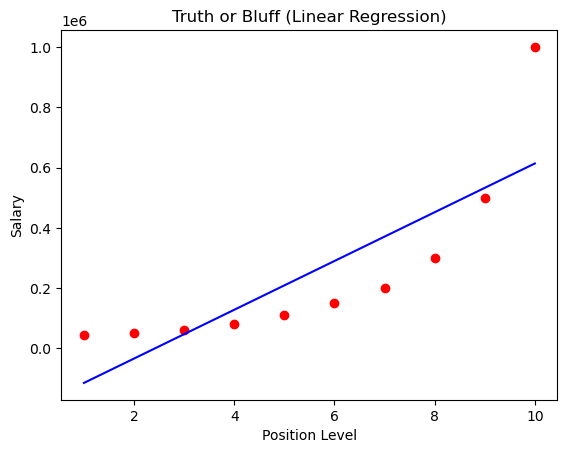

In [24]:
plt.scatter(X, y, color="red")
plt.plot(X, lin_reg.predict(X), color="blue")
plt.title("Truth or Bluff (Linear Regression)")
plt.xlabel("Position Level")
plt.ylabel("Salary")
plt.show()

## Visualizing the polynomial regression results

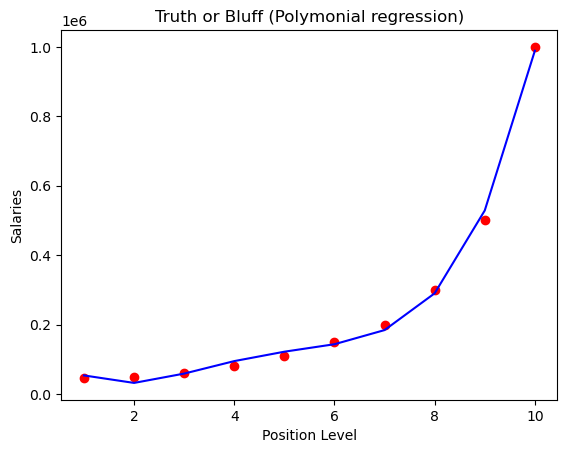

In [25]:
plt.scatter(X, y, color = 'red')
plt.plot(X, lin_reg_2.predict(X_poly), color = 'blue')
plt.title('Truth or Bluff (Polymonial regression)')
plt.xlabel('Position Level')
plt.ylabel('Salaries')
plt.show()

## Visualizing the polynomial regression results (higher resolution and smoother curve)

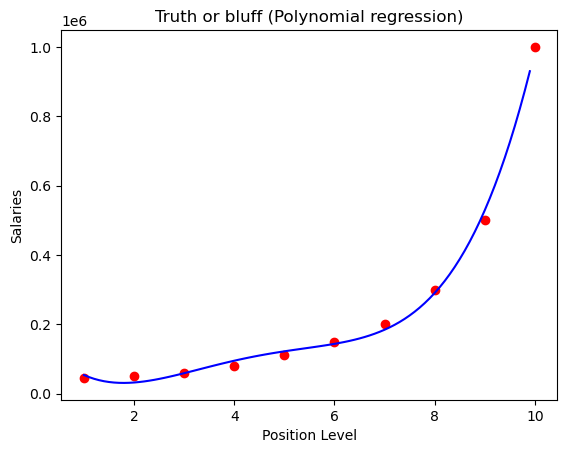

In [ ]:
X_grid = np.arange(X.min(), X.max(), 0.1) # occhio che X è un array 2D, quindi bisogna prendere la colonna
X_grid = X_grid.reshape(len(X_grid), 1)
plt.scatter(X, y, color = 'red')
plt.plot(X_grid, lin_reg_2.predict(poly_reg.fit_transform(X_grid)), color = 'blue')
plt.title('Truth or bluff (Polynomial regression)')
plt.xlabel('Position Level')
plt.ylabel('Salaries')
plt.show()

## Predict a new result with linear regression

In [ ]:
lin_reg.predict([[6.5]]) # totalmete fuori scala, quindi possiamo concludere chenon è affidabile

array([[330378.78787879]])

## Predict a new result with polynomial regression

In [ ]:
lin_reg_2.predict(poly_reg.fit_transform([[6.5]])) # molto più affidabile

array([[158862.45265152]])